In [32]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_utils import load_sql
import joblib
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Библиотеки импортированы")

Библиотеки импортированы


In [ ]:
MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'

print(f"Загружаем модель {MODEL_NAME}...")
embedder = SentenceTransformer(MODEL_NAME)
print("Модель загружена!")

Загружаем модель paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\Duck\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Duck\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Модель загружена!


In [24]:
sentences = [
    "Этот фильм просто шедевр, всем рекомендую!",
    "Отличное кино, превосходная игра актёров.",
    "Ужасный фильм, зря потратил время.",
    "Фильм был плохой и скучный.",
    "Фильм как фильм, ничего особенного.",
    "Я люблю пиццу с сыром."
]

embeddings = embedder.encode(sentences)

print(f"   Размер массива: {embeddings.shape}")
print(f"   Количество фраз: {embeddings.shape[0]}")
print(f"   Размер каждого вектора: {embeddings.shape[1]}")

   Размер массива: (6, 384)
   Количество фраз: 6
   Размер каждого вектора: 384


Фраза: 'Этот фильм просто шедевр, всем рекомендую!'

Первые 10 чисел вектора: [-0.31563857 -0.07254659 -0.4270254  -0.1021687  -0.02438198  0.19005822
  0.18263163  0.21760376 -0.07325966 -0.09457596]
Минимум: -0.5555
Максимум: 0.5567
Среднее: -0.0005


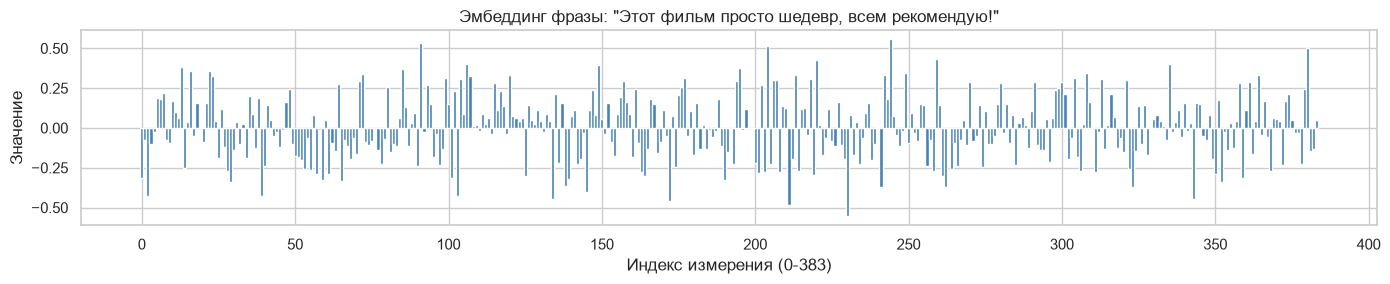

In [25]:
vec = embeddings[0]

print(f"Фраза: '{sentences[0]}'")
print(f"\nПервые 10 чисел вектора: {vec[:10]}")
print(f"Минимум: {vec.min():.4f}")
print(f"Максимум: {vec.max():.4f}")
print(f"Среднее: {vec.mean():.4f}")

plt.figure(figsize=(14, 3))
plt.bar(range(len(vec)), vec, width=1, color='steelblue')
plt.title(f'Эмбеддинг фразы: "{sentences[0]}"')
plt.xlabel('Индекс измерения (0-383)')
plt.ylabel('Значение')
plt.tight_layout()
plt.savefig('../data/processed/embedding_example0.png', dpi=150)
plt.show()

 Размер матрицы сходства: (6, 6)


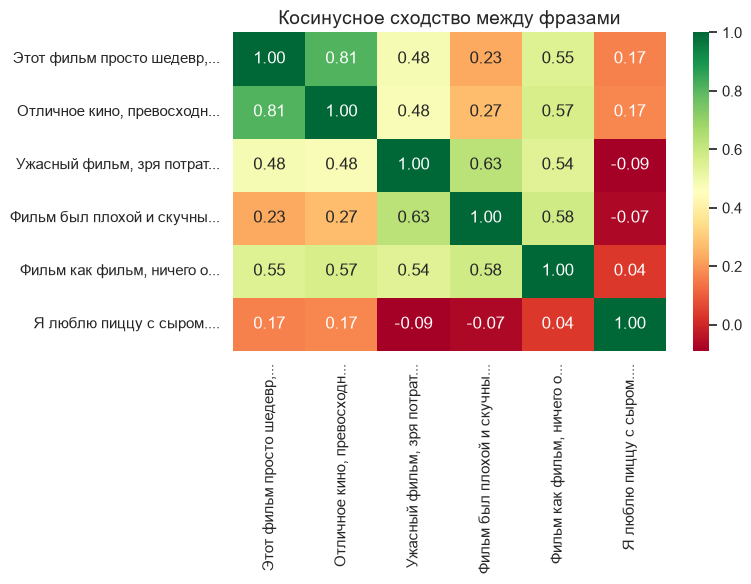

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

print(f" Размер матрицы сходства: {similarity_matrix.shape}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    similarity_matrix,
    annot=True,           # показываем числа
    fmt='.2f',            # 2 знака после запятой
    cmap='RdYlGn',        # красный → жёлтый → зелёный
    xticklabels=[s[:25] + '...' for s in sentences],
    yticklabels=[s[:25] + '...' for s in sentences],
    ax=ax
)
plt.title('Косинусное сходство между фразами', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/similarity_matrix.png', dpi=150)
plt.show()

In [27]:
def find_most_similar(query, sentences, embeddings, top_n: int = 3):

    query_embedding = embedder.encode([query])
    
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    top_indices = np.argsort(similarities)[::-1][:top_n]
    
    print(f"Запрос: '{query}'\n")
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}. [{similarities[idx]:.3f}] {sentences[idx]}")

find_most_similar("мне очень понравилось это кино", sentences, embeddings)
print()
find_most_similar("плохой фильм, не рекомендую", sentences, embeddings)

Запрос: 'мне очень понравилось это кино'

  1. [0.767] Этот фильм просто шедевр, всем рекомендую!
  2. [0.708] Отличное кино, превосходная игра актёров.
  3. [0.452] Фильм как фильм, ничего особенного.

Запрос: 'плохой фильм, не рекомендую'

  1. [0.707] Фильм как фильм, ничего особенного.
  2. [0.697] Фильм был плохой и скучный.
  3. [0.681] Ужасный фильм, зря потратил время.


In [ ]:
df = load_sql("SELECT * FROM documents")

df_sample = df.sample(500, random_state=42).reset_index(drop=True)

print(f"Работаем с {len(df_sample)} отзывами")
print(f"Распределение:\n{df_sample['category'].value_counts()}")

Работаем с 50000 отзывами
Распределение:
category
pos    33041
neu     9500
neg     7459
Name: count, dtype: int64


In [73]:
print("Векторизуем отзывы через эмбеддинги...")
review_embeddings = embedder.encode(
    df_sample['text'].tolist(),
    show_progress_bar=True,
    batch_size=32 
)

print(f"Готово! Размер: {review_embeddings.shape}")

Векторизуем отзывы через эмбеддинги...


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Готово! Размер: (50000, 384)


In [76]:
print("Считаем t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=3000)
embeddings_2d = tsne.fit_transform(review_embeddings)

df_sample['x'] = embeddings_2d[:, 0]
df_sample['y'] = embeddings_2d[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'neg': '#e74c3c', 'neu': "#481fdd", 'pos': '#2ecc71'}
for cat in ['neg', 'neu', 'pos']:
    subset = df_sample[df_sample['category'] == cat]
    ax.scatter(subset['x'], subset['y'], 
               c=colors[cat], label=cat, alpha=0.6, s=20)

ax.set_title('t-SNE визуализация эмбеддингов отзывов', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/tsne_embeddings.png', dpi=150)
plt.show()

Считаем t-SNE...


KeyboardInterrupt: 

Считаем t-SNE для TF-IDF...


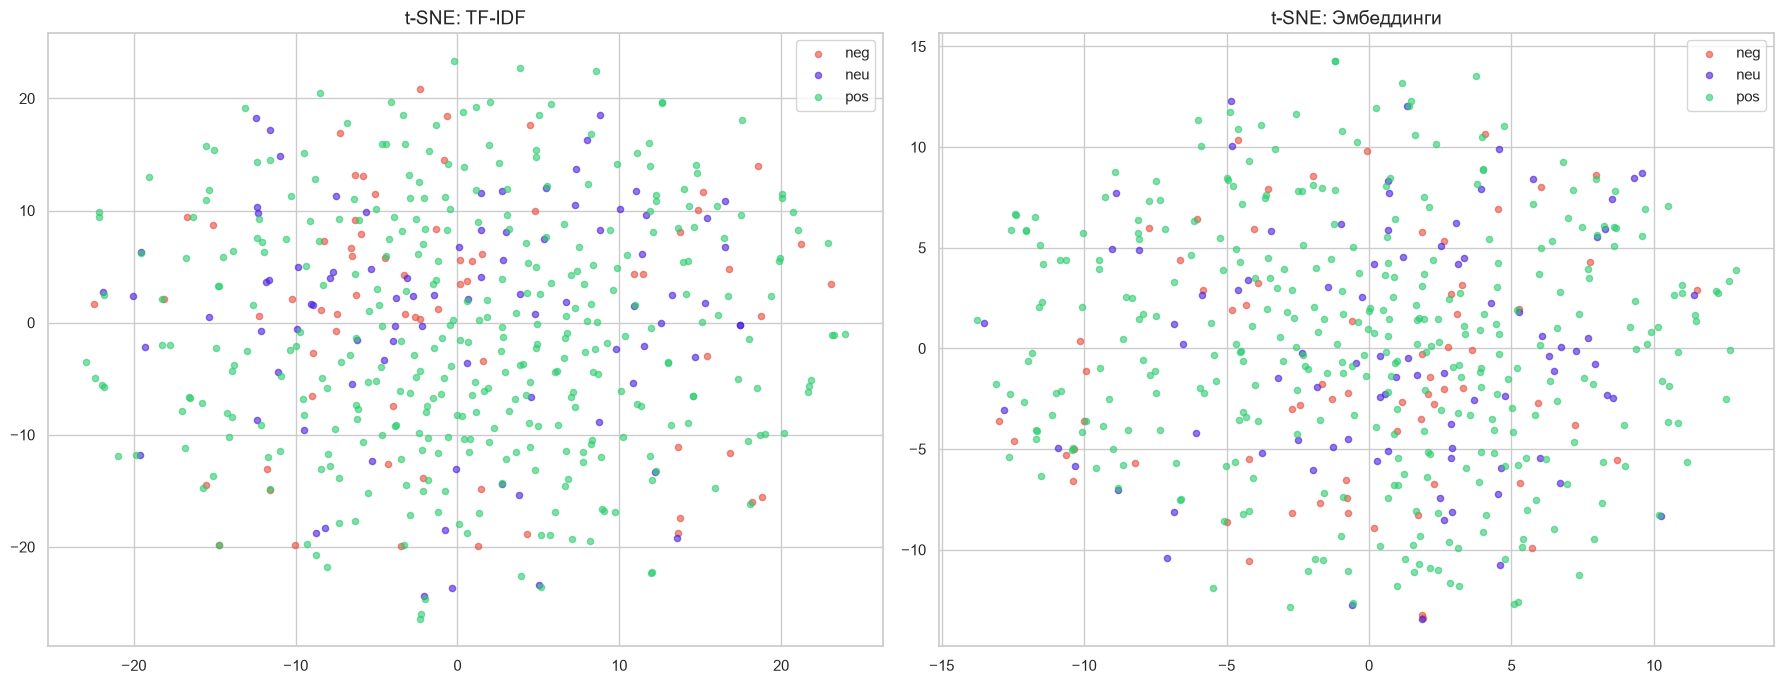

In [70]:
vectorizer = joblib.load('../models/tfidf_vectorizer_v1.pkl')

tfidf_matrix = vectorizer.transform(df_sample['text'])

print("Считаем t-SNE для TF-IDF...")
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=30)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix.toarray())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for cat in ['neg', 'neu', 'pos']:
    mask = df_sample['category'] == cat
    axes[0].scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1],
                    c=colors[cat], label=cat, alpha=0.6, s=20)
axes[0].set_title('t-SNE: TF-IDF', fontsize=14)
axes[0].legend()

for cat in ['neg', 'neu', 'pos']:
    mask = df_sample['category'] == cat
    axes[1].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    c=colors[cat], label=cat, alpha=0.6, s=20)
axes[1].set_title('t-SNE: Эмбеддинги', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/tsne_comparison.png', dpi=150)
plt.show()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Векторизуем через русскую модель...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

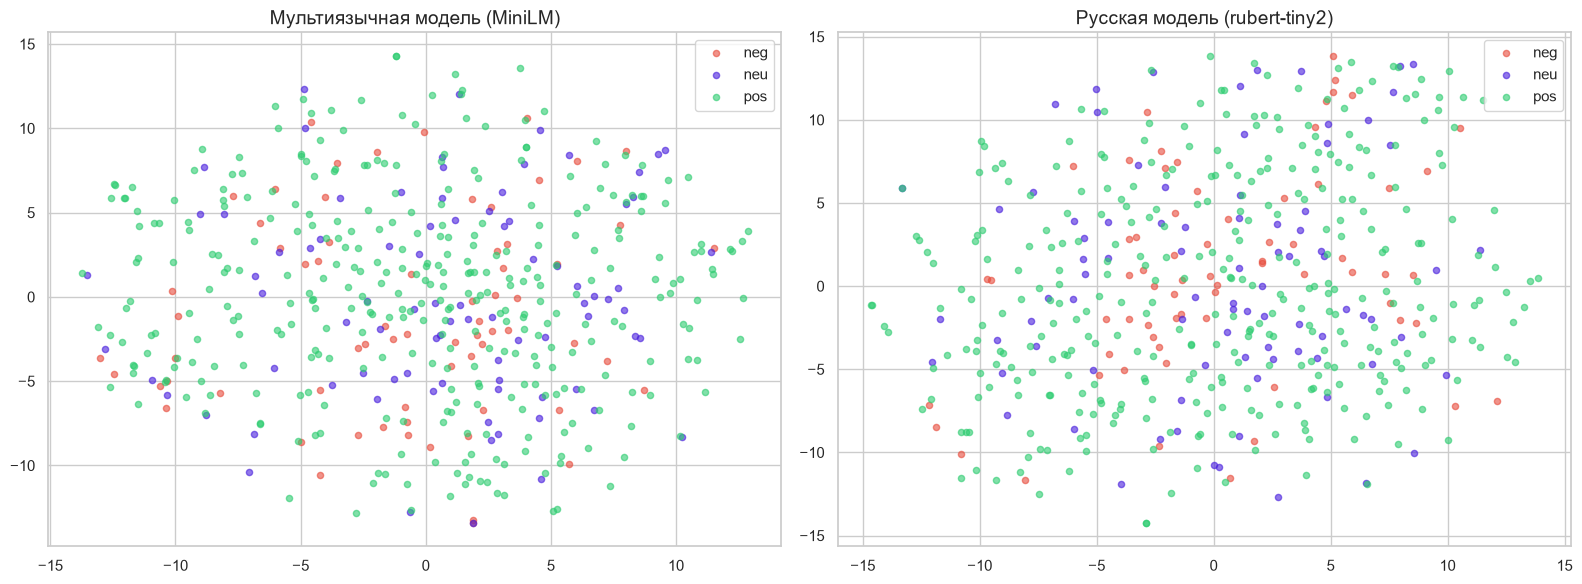

In [71]:
embedder_ru = SentenceTransformer('cointegrated/rubert-tiny2')

print("Векторизуем через русскую модель...")
review_embeddings_ru = embedder_ru.encode(
    df_sample['text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

tsne_ru = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
embeddings_2d_ru = tsne_ru.fit_transform(review_embeddings_ru)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cat in ['neg', 'neu', 'pos']:
    mask = df_sample['category'] == cat
    axes[0].scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                    c=colors[cat], label=cat, alpha=0.6, s=20)
axes[0].set_title('Мультиязычная модель (MiniLM)', fontsize=14)
axes[0].legend()

for cat in ['neg', 'neu', 'pos']:
    mask = df_sample['category'] == cat
    axes[1].scatter(embeddings_2d_ru[mask, 0], embeddings_2d_ru[mask, 1],
                    c=colors[cat], label=cat, alpha=0.6, s=20)
axes[1].set_title('Русская модель (rubert-tiny2)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()

📐 После PCA: (500, 50)
Объяснённая дисперсия: 77.22%


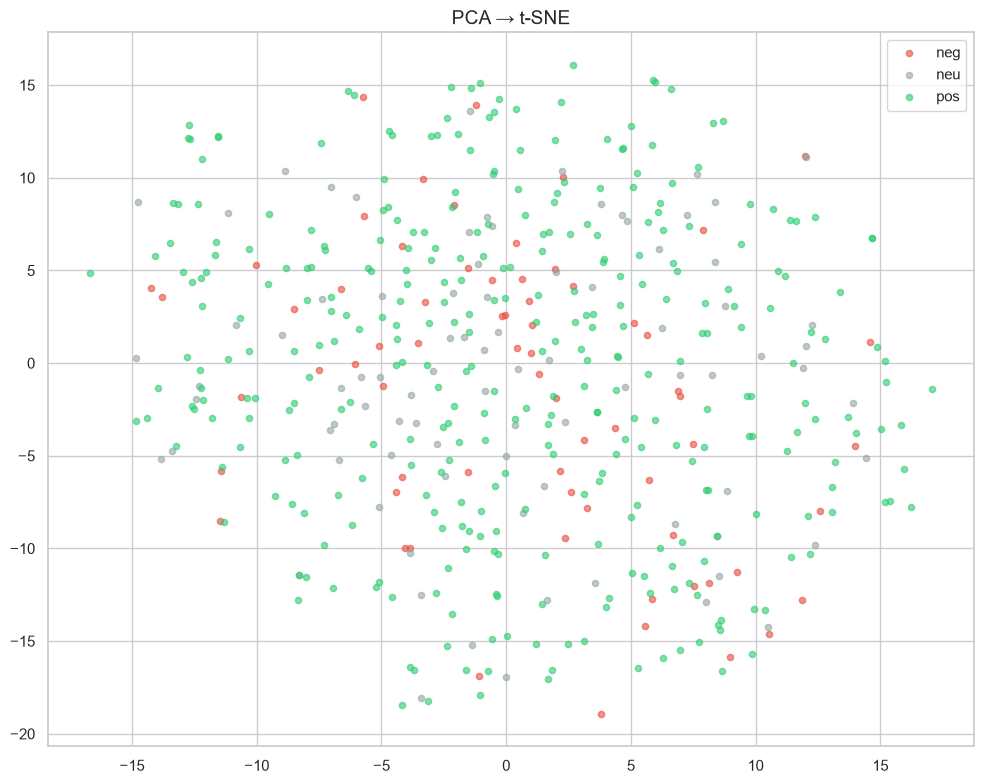

In [67]:
from sklearn.decomposition import PCA

# Сначала PCA: 384 → 50 измерений
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(review_embeddings)

print(f"📐 После PCA: {embeddings_pca.shape}")
print(f"Объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

# Потом t-SNE на PCA
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
embeddings_2d_pca = tsne.fit_transform(embeddings_pca)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
for cat in ['neg', 'neu', 'pos']:
    mask = df_sample['category'] == cat
    ax.scatter(embeddings_2d_pca[mask, 0], embeddings_2d_pca[mask, 1],
               c=colors[cat], label=cat, alpha=0.6, s=20)
ax.set_title('PCA → t-SNE', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/pca_tsne.png', dpi=150)
plt.show()